# 02 - Baseline: Regularised Logistic Regression
Ridge vs Lasso vs Elastic Net, tuned with 10-fold CV (as in the Stanford paper).

In [1]:
import sys; sys.path.append('..')
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
import pandas as pd
from src.train_logreg import train
model, results, best_cv = train()

Ridge       CV AUROC=0.7312 (C=0.03162)


Lasso       CV AUROC=0.7325 (C=0.1)


ElasticNet  CV AUROC=0.7326 (C=0.03162)
Best baseline: ElasticNet


In [2]:
pd.Series(results, name='CV AUROC').round(4).to_frame()

,CV AUROC
Ridge,0.7312
Lasso,0.7325
ElasticNet,0.7326


In [3]:
from src.data_preprocessing import get_split
from src.config import FEATURES
from sklearn.metrics import roc_auc_score
Xtr, Xte, ytr, yte = get_split()
print('Test AUROC: %.4f' % roc_auc_score(yte, model.predict_proba(Xte[FEATURES])[:,1]))

Test AUROC: 0.7022


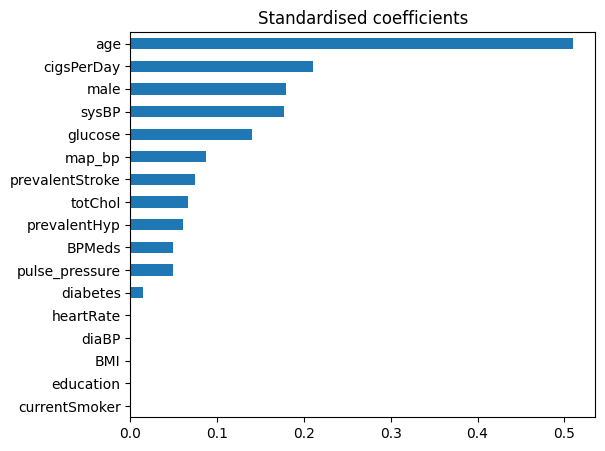

In [4]:
coef = pd.Series(model.named_steps['clf'].coef_[0], index=FEATURES).sort_values()
coef.plot.barh(figsize=(6,5), title='Standardised coefficients'); 